In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

[('cuda:1', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:6', 'NVIDIA A100-SXM4-80GB', 81043),
 ('cuda:2', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:3', 'NVIDIA A100-SXM4-80GB', 81041),
 ('cuda:0', 'NVIDIA A100-SXM4-80GB', 77857),
 ('cuda:5', 'NVIDIA A100-SXM4-80GB', 74623),
 ('cuda:4', 'NVIDIA A100-SXM4-80GB', 48393),
 ('cuda:7', 'NVIDIA A100-SXM4-80GB', 15155)]

In [2]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg)
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:2

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:2)
# edge_attr                (32464, 16)              Tensor (cuda:2)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:2)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:2)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

In [3]:
_dataset[0].num_nodes

4373

In [4]:
_dataset.print_dims()

# #### GraphDataset(), Dataset ####
# num_graphs (len)         1172                     int
# num_node_features        1                        int
# num_edge_features        16                       int

# #### GraphDataset(), Data ####
# num_nodes                4373                     int
# num_edges                32464                    int
# num_node_features        1                        int
# num_edge_features        16                       int

# #### GraphDataset(), Summary ####
# Average node degree      0.1347                   float
# Has isolated nodes       True                     bool
# Has self-loops           True                     bool
# Directionality           directed                 str



---

In [5]:
import modules.model as m
import modules.layers as l
import modules.train as t
import torch.nn as nn

model = m.Autoencoder(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # layers
    nb=True,
    encoder_class=nn.Linear,
    pooling_class=l.SetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

trainer = t.NBReconTrainer(
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
)

expt = t.Experiment(
    num_trials=10,
    num_epochs=20,
    dataset=_dataset,
    generator=generator,
    batch_size=128,
)

expt.add_trainer('config1', model=model, trainer=trainer)
expt.run_experiment(comment='test_run')

100%|██████████| 10/10 [02:33<00:00, 15.35s/it]


In [6]:
expt.summary

,config,metric,mean,std,ci
0,config1,loss,10.388152,0.106218,0.075984
1,config1,mae,0.781550,0.014352,0.010267
2,config1,mean,0.028660,0.075754,0.054191
3,config1,mse,1.343836,0.037327,0.026702
4,config1,r2,0.829799,0.004034,0.002886
5,config1,rmse,1.159140,0.016030,0.011467
6,config1,std,1.156565,0.015201,0.010874


---

In [7]:
import modules.viz as v

/home/mv18gs/miniconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


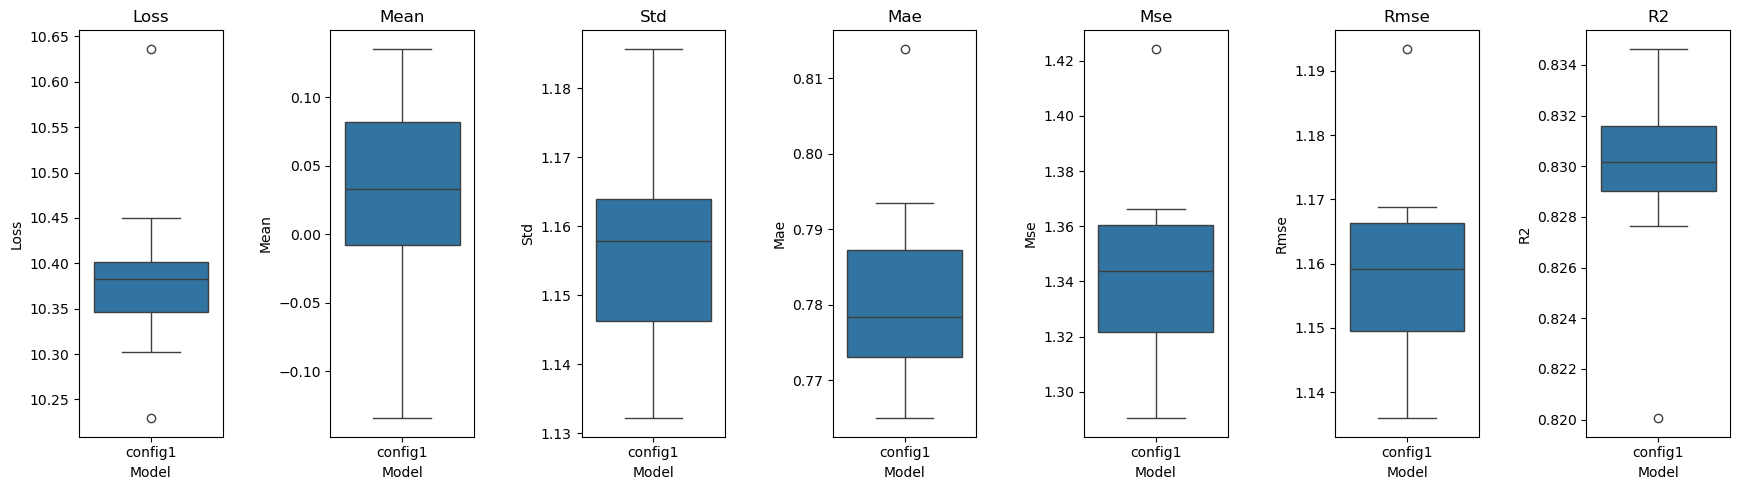

In [8]:
v.test_plot(expt.test_df)

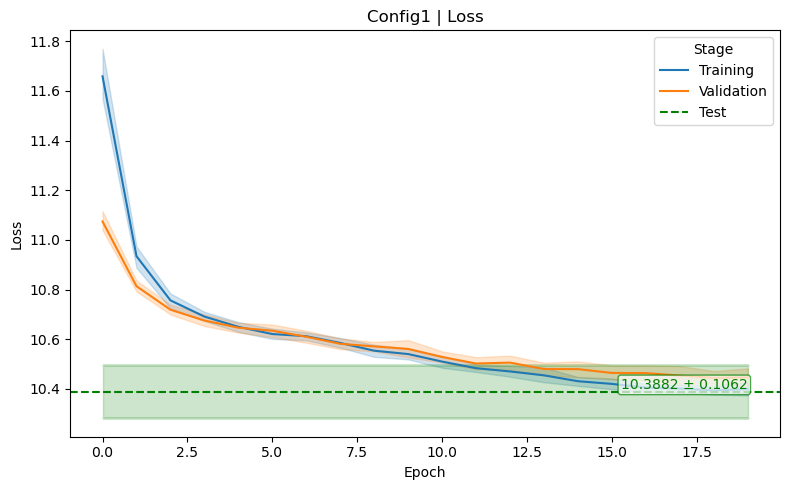

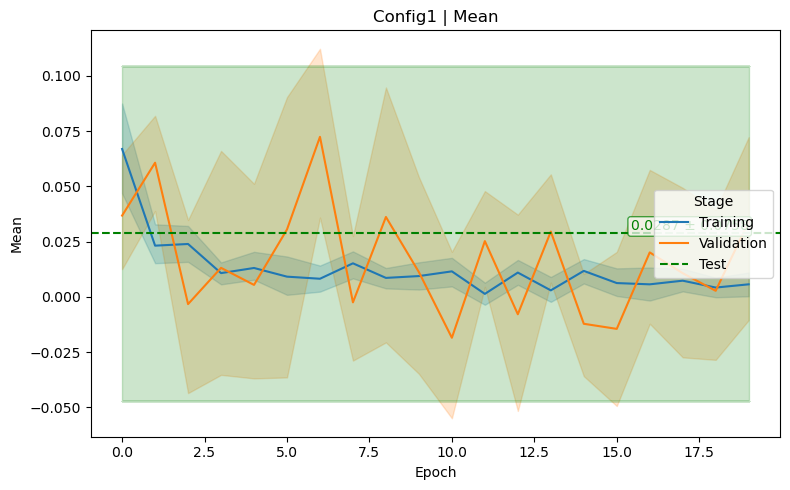

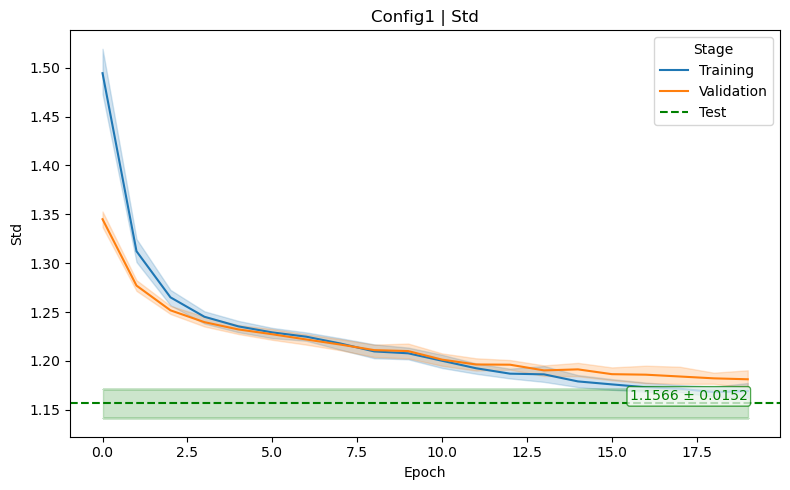

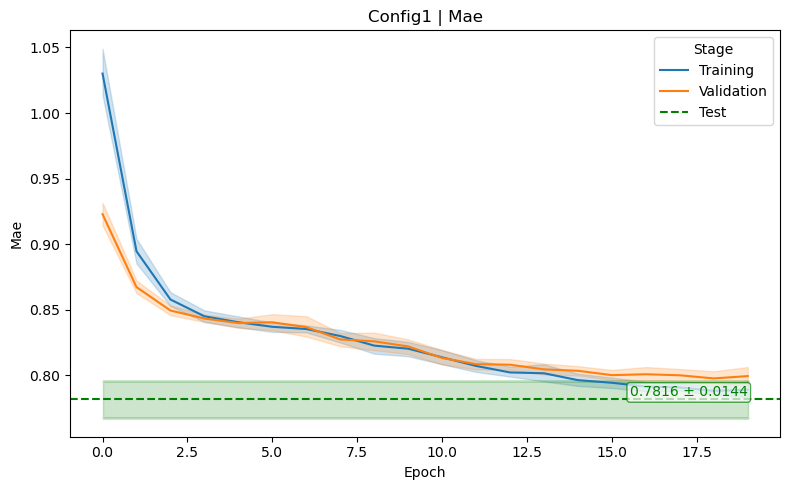

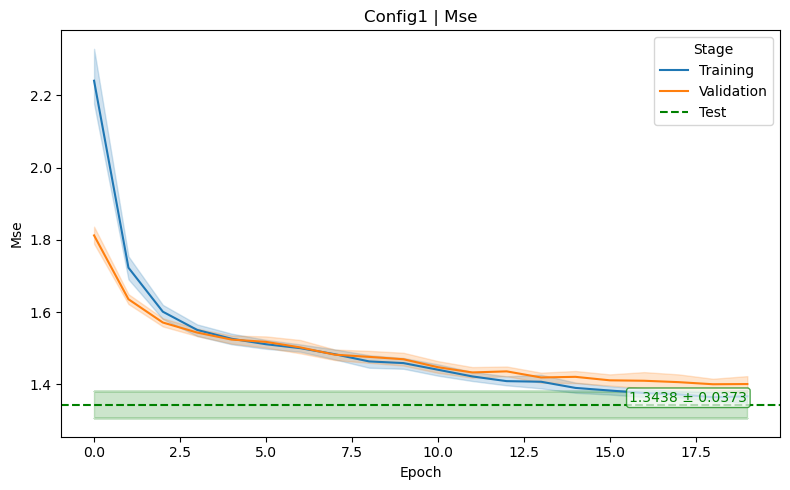

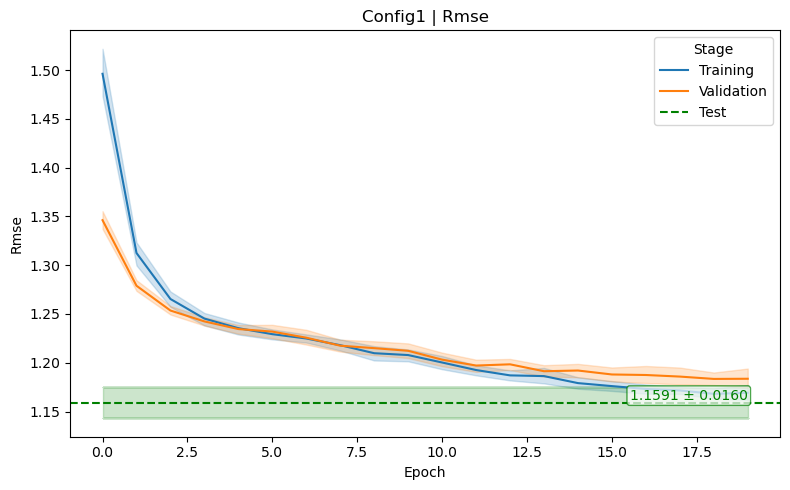

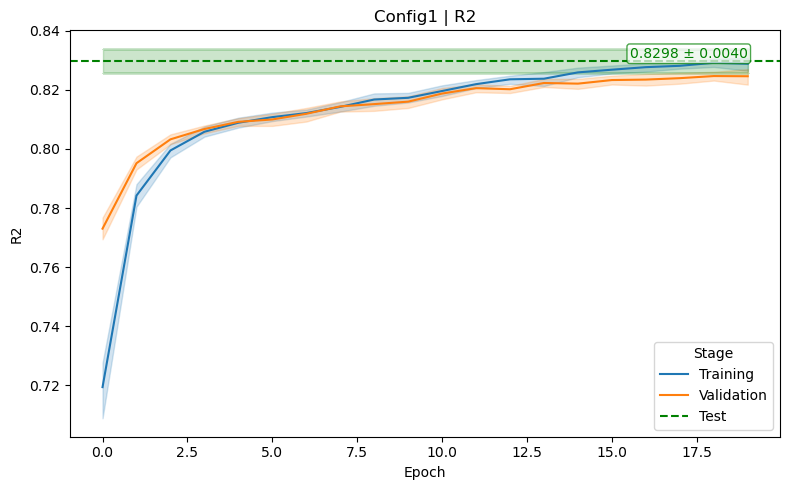

In [9]:
v.dev_plot(expt.dev_df, expt.summary)